# 02 — Memory footprint vs model size

**Headline chart of the deliverable.** This notebook produces the bar chart that answers the Intel engineer's question: *for a given model, how much system RAM does each backend's server process actually hold on Panther Lake?*

How to run it:

1. Bring up ONE backend on `:9000` (OV, vLLM, or llama.cpp) loaded with ONE model.
2. Set `BACKEND` and `MODEL` below to match what you brought up.
3. Run the notebook end-to-end. It records peak RSS + iGPU into a CSV.
4. Stop that backend. Repeat steps 1–3 for the next (backend, model) you care about.
5. The last cell loads every row in the CSV and plots them together.

The chart is cumulative across runs — you don’t need to capture every backend in one sitting.

In [14]:
import sys, pathlib, json, csv, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from bench import client, memprobe, plotting
import matplotlib.pyplot as plt

In [15]:
# ---- EDIT PER RUN ----
BACKEND        = 'vllm'                       # openvino | vllm | llamacpp
BACKEND_VER    = ''                               # auto-detected below if blank; override if needed
MODEL          = 'gemma-4-E4B-it'
PARAMS_B       = 4.0                              # approx params in billions, for the x-axis
QUANTIZATION   = 'FP16'                           # INT4 | INT8 | FP16 | FP32 | other
DEVICE         = 'iGPU'                           # iGPU | CPU | NPU | (hybrid description)
BASE_URL       = 'http://127.0.0.1:9000/v1'
CSV_PATH       = pathlib.Path('../data/memory_footprint.csv')
# ----------------------

In [16]:
pid = memprobe.find_server_pid(9000)
assert pid, 'No server listening on :9000 — bring up the backend first.'

# best-effort backend version: vLLM exposes /version, OVMS exposes it in
# response headers, optimum-cli serve has no endpoint so we read the local
# package version from the bench's venv. Operator can override BACKEND_VER above.
if not BACKEND_VER:
    import urllib.request, importlib.metadata
    detected = ''
    try:
        with urllib.request.urlopen(BASE_URL.rstrip('/v1') + '/version', timeout=1.0) as resp:
            import json as _j
            detected = (_j.loads(resp.read()) or {}).get('version', '')
    except Exception:
        pass
    if not detected:
        # local package fallback (only meaningful if THIS venv matches the server's venv)
        for pkg in ('openvino', 'vllm', 'llama-cpp-python', 'optimum-intel'):
            try:
                detected = f'{pkg}=={importlib.metadata.version(pkg)}'
                break
            except importlib.metadata.PackageNotFoundError:
                continue
    BACKEND_VER = detected or 'unknown'

print(f'server pid={pid}')
print(f'BACKEND={BACKEND}  VER={BACKEND_VER}')
print(f'MODEL={MODEL}  QUANT={QUANTIZATION}  DEVICE={DEVICE}')

server pid=2480825
BACKEND=vllm  VER=0.20.0
MODEL=gemma-4-E4B-it  QUANT=FP16  DEVICE=iGPU


In [17]:
prompts = json.loads(pathlib.Path('../data/prompts.json').read_text())['text_only']
client.warmup(base_url=BASE_URL, model=MODEL)

with memprobe.MemProbe(pid=pid, interval_s=0.5) as probe:
    for p in prompts:
        r = client.call(
            base_url=BASE_URL, model=MODEL,
            prompt=p['prompt'], max_tokens=p['max_tokens'],
            stream=False,
        )
        print(f"{p['id']:>10}  {r.total_latency_s:5.2f}s  {r.completion_tokens:4d} tok")
    # let RSS settle for one more sampling window so peak is well-captured
    time.sleep(2.0)

peak = probe.peak()
base = probe.baseline()
print(f'\npeak RSS  : {peak.rss_mb:8.1f} MB')
print(f'baseline  : {base.rss_mb:8.1f} MB')
peak_igpu = max((s.igpu_mb for s in probe.samples if s.igpu_mb is not None), default=None)
print(f'peak iGPU : {peak_igpu:8.1f} MB' if peak_igpu is not None else 'peak iGPU : (no intel_gpu_top reading)')

   t-short   1.08s     8 tok
  t-medium  16.84s   128 tok
    t-long  23.23s   177 tok

peak RSS  :   8868.6 MB
baseline  :   8868.6 MB
peak iGPU :  21607.8 MB


In [19]:
import datetime as _dt
CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
row = {
    'timestamp':       _dt.datetime.now().isoformat(timespec='seconds'),
    'backend':         BACKEND,
    'backend_version': BACKEND_VER,
    'model':           MODEL,
    'params_b':        PARAMS_B,
    'quantization':    QUANTIZATION,
    'device':          DEVICE,
    'peak_rss_mb':     round(peak.rss_mb, 1),
    'baseline_rss_mb': round(base.rss_mb, 1),
    'peak_igpu_mb':    round(peak_igpu, 1) if peak_igpu is not None else '',
}
header = list(row.keys())
new_file = not CSV_PATH.exists()
with CSV_PATH.open('a', newline='') as f:
    w = csv.DictWriter(f, fieldnames=header)
    if new_file:
        w.writeheader()
    w.writerow(row)
print('appended to', CSV_PATH)
print({k: v for k, v in row.items() if k in ('timestamp','backend','model','peak_rss_mb','peak_igpu_mb')})

appended to ../data/memory_footprint.csv
{'timestamp': '2026-05-26T13:35:09', 'backend': 'vllm', 'model': 'gemma-4-E4B-it', 'peak_rss_mb': 8868.6, 'peak_igpu_mb': 21607.8}


## All runs so far

Re-run the cell below after each (backend, model) capture to refresh the chart.

8 rows in CSV:
  openvino  gemma-4-E4B-it-int4-ov               INT4/iGPU    7.28 GB RSS  6785 MB iGPU
  openvino  gemma-4-E4B-it-int4-ov               INT4/iGPU    7.29 GB RSS  6794 MB iGPU
  vllm      gemma-4-E4B-it                       FP16/iGPU    8.66 GB RSS  21608 MB iGPU
  vllm      gemma-4-E4B-it                       FP16/iGPU    8.66 GB RSS  21608 MB iGPU
  vllm      gemma-4-E4B-it                       FP16/iGPU    8.66 GB RSS  21608 MB iGPU
  vllm      gemma-4-E4B-it                       FP16/iGPU    8.66 GB RSS  21608 MB iGPU
  vllm      gemma-4-E4B-it                       FP16/iGPU    8.66 GB RSS  21608 MB iGPU
  vllm      gemma-4-E4B-it                       FP16/iGPU    8.66 GB RSS  21608 MB iGPU


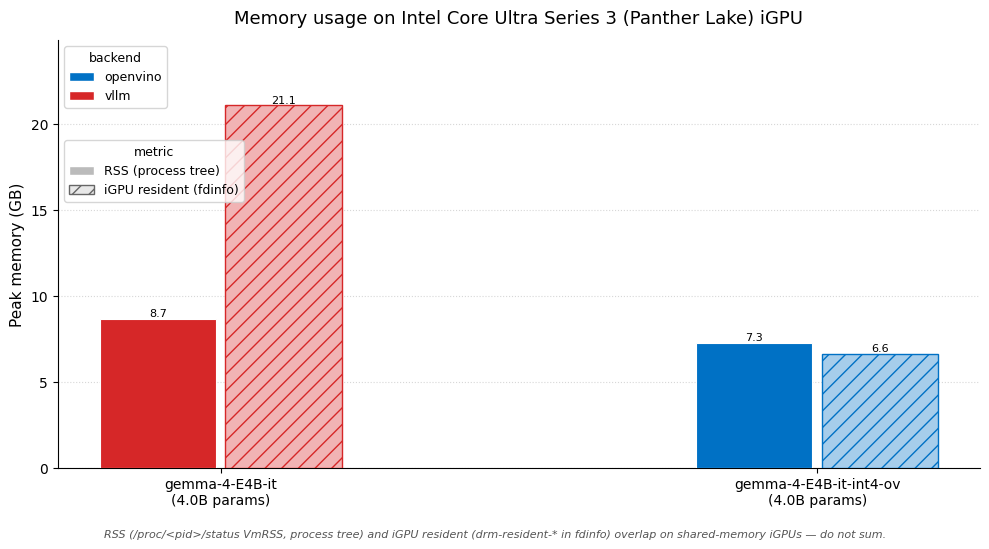

In [20]:
rows = []
with CSV_PATH.open() as f:
    for r in csv.DictReader(f):
        rows.append({
            'backend':      r['backend'],
            'model':        r['model'],
            'params_b':     float(r['params_b']),
            'quantization': r.get('quantization', ''),
            'device':       r.get('device', ''),
            'peak_rss_mb':  float(r['peak_rss_mb']),
            'peak_igpu_mb': float(r['peak_igpu_mb']) if r['peak_igpu_mb'] else None,
        })

# show provenance inline so the chart is self-explanatory
import itertools
print(f'{len(rows)} rows in CSV:')
for backend, group in itertools.groupby(sorted(rows, key=lambda r: r['backend']), key=lambda r: r['backend']):
    for r in group:
        igpu = f"{r['peak_igpu_mb']:.0f} MB iGPU" if r['peak_igpu_mb'] is not None else 'no iGPU'
        print(f"  {backend:9s} {r['model']:35s} {r['quantization']:>5s}/{r['device']:<6s} {r['peak_rss_mb']/1024:5.2f} GB RSS  {igpu}")

# Reload plotting in case bench/plotting.py changed since kernel start.
import importlib, bench.plotting
importlib.reload(bench.plotting)
from bench import plotting

ax = plotting.memory_vs_model_size(
    rows,
    title='Memory usage on Intel Core Ultra Series 3 (Panther Lake) iGPU',
    backend_order=['openvino', 'vllm', 'llamacpp'],
)
import matplotlib.pyplot as plt
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [4]:
# Time-series of THIS run (the bar chart above is across all runs).
ax = plotting.memory_timeseries({f'{BACKEND} {MODEL}': probe.samples})
plt.tight_layout(); plt.show()

NameError: name 'probe' is not defined